In [14]:
import slmcontrol
import numpy as np
import matplotlib.pyplot as plt
from common.utils import generate_amplitude_and_phase_hologram, zoomfft2, fidelity, remove_background
import h5py
from custom_devices.custom_ximea import CustomXimea
from pathlib import Path
import tomllib
from slm_camera_calibration import CalibrationResult

In [20]:
result_directory = Path("results/test")

config_path = result_directory / "config.toml"
with config_path.open("rb") as file:
    config = tomllib.load(file)
N = config["grid"]["size"]

calibration_path = result_directory / "calibration_data" / "calibration.h5"

with h5py.File(calibration_path) as f:
    calibration_image = np.asarray(f["calibration_image"])
    zoom = float(f["zoom"][()])

_xs = np.arange(N) - N // 2
_ys = np.arange(N) - N // 2
xs, ys = np.meshgrid(_xs, _ys)

Fidelity: 0.9524190576629281


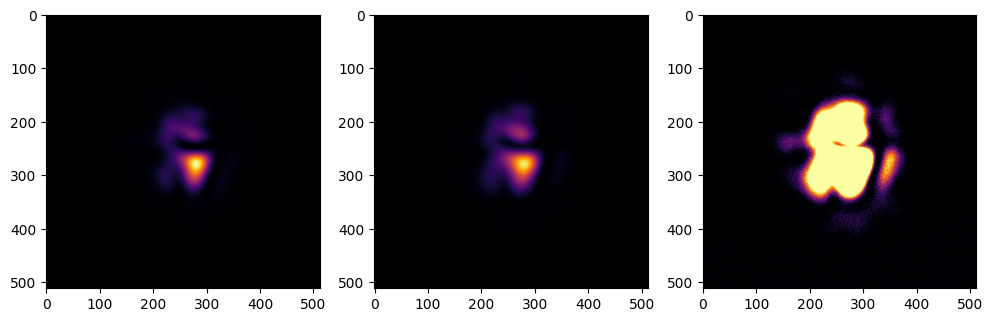

In [25]:
sigma_idx = 0
phase_idx = 0
coeff_idx = 0

with h5py.File(result_directory / "phases.h5") as f:
    phase = np.asarray(f["phases"][sigma_idx, phase_idx])
    
order_folder = "up_to_order_2"


with h5py.File(result_directory / order_folder / "modes.h5") as f:
    basis = np.asarray(f["basis"])
    coeff = np.asarray(f["coefficients"][coeff_idx])

with h5py.File(result_directory / order_folder / "data.h5") as f:
    image_experiment = remove_background(f["images_phase_fourier"][sigma_idx, phase_idx, coeff_idx], 4)

slm = slmcontrol.SLMDisplay(host="localhost")

try:
    u = np.sum(coeff.reshape(-1, 1, 1) * basis, axis=0)
    # u = slmcontrol.lg(xs, ys, l=2, w=30)
    # phase = -np.angle(u)
    holo = generate_amplitude_and_phase_hologram(u, phase, 192, 4, np.inf, slm_shape=(slm.height, slm.width // 2))
    slm.updateArray(holo)

    # with CustomXimea() as camera:
    #     camera.set_exposure(15)
    #     camera.calibrate(N, image=calibration_image)
    #     image_experiment = remove_background(camera.capture(), 4)


    ft_u = zoomfft2(u * np.exp(1j * phase), zoom)
    image_theory = np.abs(ft_u)**2

    print(f"Fidelity: {fidelity(np.abs(ft_u), np.sqrt(image_experiment.astype(np.float64)))}")

    fig, axs = plt.subplots(1, 3, figsize=(12, 8))
    axs[0].imshow(image_theory, cmap="inferno")
    axs[1].imshow(image_experiment, cmap="inferno")
    axs[2].imshow(image_experiment, cmap="inferno", vmax=10)
finally:
    slm.close()